*** This Code is for Extracting ship information from NovaSAR images and their corresponding AIS data

In [1]:
# Import dependencies

import os
import numpy as np
import math
from datetime import datetime, date
import matplotlib.pyplot as plt
import rasterio as rio



In [2]:
from functions import *

# NovaSAR images

In [3]:
head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"

# data_time = "Airbus_2024Feb23"
# data_time = "Airbus_2024Jan11"
data_time = "Airbus_2024Jun13"

In [4]:
# Directory containing the tif files:
dir_all = os.path.join(head_dir, data_time)
print(f"Processing directory: {dir_all}")

# Choose an index of a tif file to process:
tii = 2#150#3# 

Processing directory: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13


#### Tif images

ALL tif files in the directory

In [5]:
# Get a list of .tif files in the directory:

tif_files = get_file_list(dir_all)
print(f"Found {len(tif_files)} tif files.")
tif_files

Found 441 tif files.


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082440_HH_1/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082446_HH_2/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082457_HH_4/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082503_HH_5/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082508_HH_6/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_g

Chosen tif file

In [6]:
from pathlib import Path

# Sample image Full path
tii_path = Path(tif_files[tii][:-12])
parts = tii_path.parts

im_name = parts[-1]
print(f"Sample image (tii) name: {im_name}")
print(f"Sample image (tii) path:\n{tii_path}")

Sample image (tii) name: NovaSAR_01_53540_grd_13_240411_082452_HH_3
Sample image (tii) path:
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3


Time of Acquisition

In [7]:
# Find the data acquisition date from the metadata XML file:
from datetime import datetime

# srcattr_info_elem = root.find(".//Source_Attributes")
# # Extract RawDataStartTime
# elem = srcattr_info_elem.find(".//RawDataStartTime")
# acqdate0 = elem.text if elem is not None else None
# # Change the date format from 'YYYY-MM-DD HH:MM:SS.ssssss' to 'DD/MM/YYYY HH:MM:SS'
# dt = datetime.strptime(acqdate0, '%Y-%m-%d %H:%M:%S.%f')

acqdate0 = f"20{tif_files[tii][-31:-18]}" # YYYYMMDD_HHMMSS
dt = datetime.strptime(acqdate0, '%Y%m%d_%H%M%S')

acqdate = dt.strftime('%d/%m/%Y %H:%M:%S') # DD/MM/YYYY HH:MM:SS
print("Raw Data Start Time:", acqdate)

Raw Data Start Time: 11/04/2024 08:24:52


Geo and Image Information

In [8]:
# Extract Geo and Image information from the metadata XML file:
metadata_path = f"{tii_path}/metadata.xml"
geo_info = geo_info_from_metadata(metadata_path)

Ellipsoid Name: WGS84
Sampled Line Spacing: 2.50
Sampled Pixel Spacing: 2.50
SemiMajorAxis: 6378137.0
SemiMinorAxis: 6356752.3

Tie Points:
GroundControlPoint(row=0, col=0, x=11.73151044, y=54.47637723, id='7948465f-9481-4d84-b155-ce2823d488b8')
GroundControlPoint(row=0, col=1582, x=11.67376342, y=54.46588574, id='45c75ab9-0cc1-4b39-a1dc-a1f680b9bfd1')
GroundControlPoint(row=0, col=3164, x=11.6160244, y=54.45536276, id='e4d73ce3-719b-460d-a4fd-e8688c3bdd90')
GroundControlPoint(row=0, col=4747, x=11.55825406, y=54.44480108, id='9fe093df-e959-4ce1-907d-8ba9f74c2bd6')
GroundControlPoint(row=0, col=6329, x=11.500531, y=54.43421504, id='9040c25d-00fe-4c3b-a390-0b215234c629')
GroundControlPoint(row=0, col=7911, x=11.44282078, y=54.42359835, id='b885f08b-cb4e-4e65-8684-9ed3c508fd61')
GroundControlPoint(row=3165, col=0, x=11.69603104, y=54.54439462, id='424d6f61-2c31-4d3f-a296-cf672b98fcaf')
GroundControlPoint(row=3165, col=1582, x=11.6381739, y=54.53388586, id='19f025f0-c6e5-421b-bedb-bb872fa

#### Correct Georeferencing Error

Image Initial Transformation matrix (based on metadata)

In [9]:
# Generate CRS and transform using ellipsoid and tiepoints information extracted from the metadata XML file:
from rasterio.crs import CRS

# Use ellipsoid parameters for CRS, fallback to WGS84 if not available
if geo_info['ellipsoid'] == "WGS84":
    crs = CRS.from_epsg(4326)
else:
    crs = CRS.from_string(f"+proj=longlat +a={geo_info['SemiMajorAxis_name']} +b={geo_info['SemiMinorAxis_name']} +no_defs")

transform0 = rio.transform.from_gcps(geo_info['tiepoints'])
print("Initial Georeferencing Transformation Matrix:", transform0)

Initial Georeferencing Transformation Matrix: |-0.00,-0.00, 11.73|
|-0.00, 0.00, 54.48|
| 0.00, 0.00, 1.00|


New tiepoint pairs

In [10]:
# Load the modified tie points (based on OSM and NovaSAR images) from shapefiles

# Find the index of 'NovaSAR' in the path parts
parts = tii_path.parts
nova_index = parts.index('NovaSAR')

nova_path = Path(*parts[:nova_index + 1])

tie_im_path = f"{nova_path}/modified tie points/im_points.shp"
tie_osm_path = f"{nova_path}/modified tie points/osm_points.shp"

 Relative transformation between the image (incorrect georeferencing) and OSM (correct georeferencing)

In [11]:
delta = relative_transform_im_osm(tie_im_path, tie_osm_path)

Relative Transform: | 1.00,-0.00, 0.10|
|-0.00, 1.00,-0.03|
| 0.00, 0.00, 1.00|


In [12]:
# Save the delta transform to a JSON file
import json
# Convert to list and save
with open(f"{nova_path}/delta_transform.json", "w") as f:
    json.dump(list(delta), f)

Load the Relative transformation (between image and OSM)

In [13]:
# Load the delta transform from the saved JSON file
import json


# Find the index of 'NovaSAR' in the path parts
nova_index = parts.index('NovaSAR')

# Reconstruct the path up to and including 'NovaSAR'
nova_path = Path(*parts[:nova_index + 1])


with open(f"{nova_path}/delta_transform.json", "r") as f:
    delta_values = json.load(f)

# Reconstruct the Affine transform
from rasterio.transform import Affine
delta = Affine(*delta_values)


Corrected Transformation

In [14]:
# Corrected transformation matrix
transform=delta*transform0
transform

Affine(-3.650880073964113e-05, -1.1343314048859417e-05, 11.721433906223204,
       -6.687102054753052e-06, 2.1484736428163533e-05, 54.46975681730277)

Generate a new geotif with corrected georeferencing

In [15]:
new_geotif(tif_file_path = tif_files[tii], transform = transform, crs = crs, out_file_path = f"{tii_path}image_HH_corrected.tif")


Saved corrected image to /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3image_HH_corrected.tif


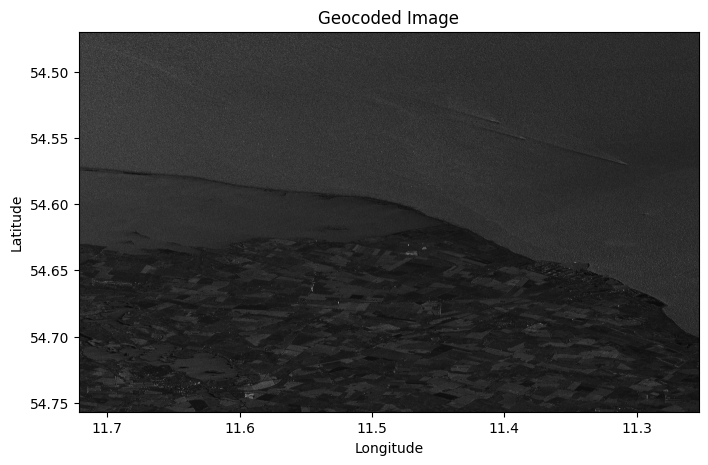

In [16]:
import rasterio.plot
src = rio.open(tif_files[tii])
im = src.read(1)
im_uint8 = (255*im/1500).astype(np.uint8)
fig, ax = plt.subplots(figsize=(8, 8))
rio.plot.show(im, ax=ax, transform=transform, cmap='gray', vmin=0, vmax=1500)
ax.set_title("Geocoded Image")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

#### AIS

In [17]:
# AIS data Path:

# ais_name = f"aisdk-{acqdate0[:10]}"  # Extract the date part (YYYY-MM-DD)       
ais_name = f"aisdk-{acqdate0[:8][:4]}-{acqdate0[:8][4:6]}-{acqdate0[:8][6:8]}"  # Extract the date part (YYYY-MM-DD)       

csv_dir = f"{head_dir}AIS_dataset/{ais_name}/{ais_name}.csv" 
# csv_dir = r"E:\AssenSAR\CSP LIDAR Data\NovaSAR\AIS_dataset\aisdk-2024-04-15\aisdk-2024-04-15.csv" 

print(f"AIS file name: {ais_name}")
print(f"AIS data CSV file path: {csv_dir}")


AIS file name: aisdk-2024-04-11
AIS data CSV file path: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/AIS_dataset/aisdk-2024-04-11/aisdk-2024-04-11.csv


Find Lat and Lon extent in the image

In [18]:
lat_min, lon_min, lat_max, lon_max = get_geotif_LatLon_extent(f'{tii_path}image_HH_corrected.tif')

print(f"Latitude extent: {lat_min} to {lat_max}")
print(f"Longitude extent: {lon_min} to {lon_max}")

Latitude extent: 54.41684846584557 to 54.80973128654203
Longitude extent: 11.253079673262013 to 11.721433906223204


Extract the Corresponding AIS data for the date and spatial extent of the SAR image

In [36]:
time_buffer = [1,2]  # seconds
AIS_df = load_AIS_df(csv_dir, acqdate, lat_min, lon_min, lat_max, lon_max, time_buffer)

In [37]:
AIS_df

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,11/04/2024 08:24:51,Class A,245258000,54.525982,11.372965,Under way using engine,0.0,14.3,107.6,110.0,...,170.0,GPS,9.0,PLGDY VIA NOK,12/04/2024 07:00:00,AIS,156.0,14.0,13.0,13.0
3,11/04/2024 08:24:51,Class A,209453000,54.634110,11.381472,Restricted maneuverability,NaN,0.0,278.8,NaN,...,60.0,GPS,2.6,RODBY HAVN,NaN,AIS,50.0,10.0,9.0,9.0
5,11/04/2024 08:24:51,Class A,212701000,54.624732,11.360080,Restricted maneuverability,NaN,2.4,225.1,226.0,...,48.0,Internal,2.9,DREDGING,19/05/2024 03:40:00,AIS,8.0,40.0,11.0,4.0
7,11/04/2024 08:24:51,Class A,209808000,54.657328,11.350060,Under way using engine,0.0,0.0,0.0,317.0,...,30.0,GPS,3.2,FEMERN BLT WRK VSL,11/03/2025 16:00:00,AIS,12.0,18.0,4.0,6.0
10,11/04/2024 08:24:51,Class A,636021680,54.528218,11.465165,Under way using engine,0.0,14.3,298.0,300.0,...,167.0,GPS,7.2,RUULU > DKSKA,12/04/2024 10:00:00,AIS,147.0,20.0,18.0,5.0
11,11/04/2024 08:24:52,Class A,245693000,54.633958,11.381553,Under way using engine,0.0,0.0,310.4,254.0,...,30.0,GPS,2.8,FBC CONSTR VESSEL,07/03/2025 23:00:00,AIS,15.0,15.0,1.0,12.0
14,11/04/2024 08:24:52,Class A,244181000,54.624132,11.359225,Under way using engine,NaN,2.3,207.5,211.0,...,32.0,GPS,3.0,RODBYHAVN,03/04/2024 20:00:00,AIS,10.0,22.0,3.0,6.0
16,11/04/2024 08:24:52,Class A,244750806,54.657052,11.350605,Under way using engine,0.0,0.0,337.0,316.0,...,22.0,GPS,1.6,SURVEY TUNNELPROJECT,03/04/2024 09:00:00,AIS,11.0,11.0,3.0,3.0
18,11/04/2024 08:24:52,Class A,211188000,54.637150,11.327800,Under way using engine,-2.2,13.7,26.1,27.0,...,141.0,GPS,5.6,DEPUT <-> DKROD,31/12/2024 12:00:00,AIS,17.0,124.0,12.0,12.0
21,11/04/2024 08:24:52,Class A,219000431,54.623133,11.305883,Under way using engine,-1.1,15.1,204.2,206.0,...,141.0,GPS,5.5,ROEDBY<->PUTTGARDEN,31/12/2024 00:00:00,AIS,22.0,119.0,13.0,13.0


In [38]:
# Save the filtered AIS data to a CSV file:
AIS_df.to_csv(f"{tii_path}/AIS.csv", index=False)
print(f"Saved AIS data to {tii_path}/AIS.csv")

Saved AIS data to /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/AIS.csv


### Extract Patches

Extract row and column indices corresponding to the AIS samples

In [39]:
row_AIS, col_AIS = AIS_row_col_from_lat_lon(lat_AIS = AIS_df['Latitude'], lon_AIS = AIS_df['Longitude'], im_path=f'{tii_path}/image_HH_corrected.tif')

Row: 5122, Col: 7995, Lat: 54.525982, Lon: 11.372965
Row: 9625, Col: 6337, Lat: 54.63411, Lon: 11.381472
Row: 9395, Col: 6996, Lat: 54.624732, Lon: 11.36008
Row: 10851, Col: 6809, Lat: 54.657328, Lon: 11.35006
Row: 4499, Col: 5666, Lat: 54.528218, Lon: 11.465165
Row: 9618, Col: 6337, Lat: 54.633958, Lon: 11.381553
Row: 9377, Col: 7025, Lat: 54.624132, Lon: 11.359225
Row: 10835, Col: 6799, Lat: 54.657052, Lon: 11.350605
Row: 10171, Col: 7634, Lat: 54.63715, Lon: 11.3278
Row: 9749, Col: 8368, Lat: 54.623133, Lon: 11.305883
Row: 3689, Col: 5207, Lat: 54.513843, Lon: 11.49128
Row: 9615, Col: 6333, Lat: 54.633917, Lon: 11.381717
Row: 10786, Col: 6847, Lat: 54.655675, Lon: 11.349448
Row: 9838, Col: 6474, Lat: 54.637772, Lon: 11.373997
Row: 10849, Col: 6828, Lat: 54.657162, Lon: 11.349413
Row: 7343, Col: 5717, Lat: 54.589123, Lon: 11.430443
Row: 7626, Col: 7255, Lat: 54.584875, Lon: 11.37105
Row: 9888, Col: 6466, Lat: 54.638895, Lon: 11.373722


Plot the image and AIS points

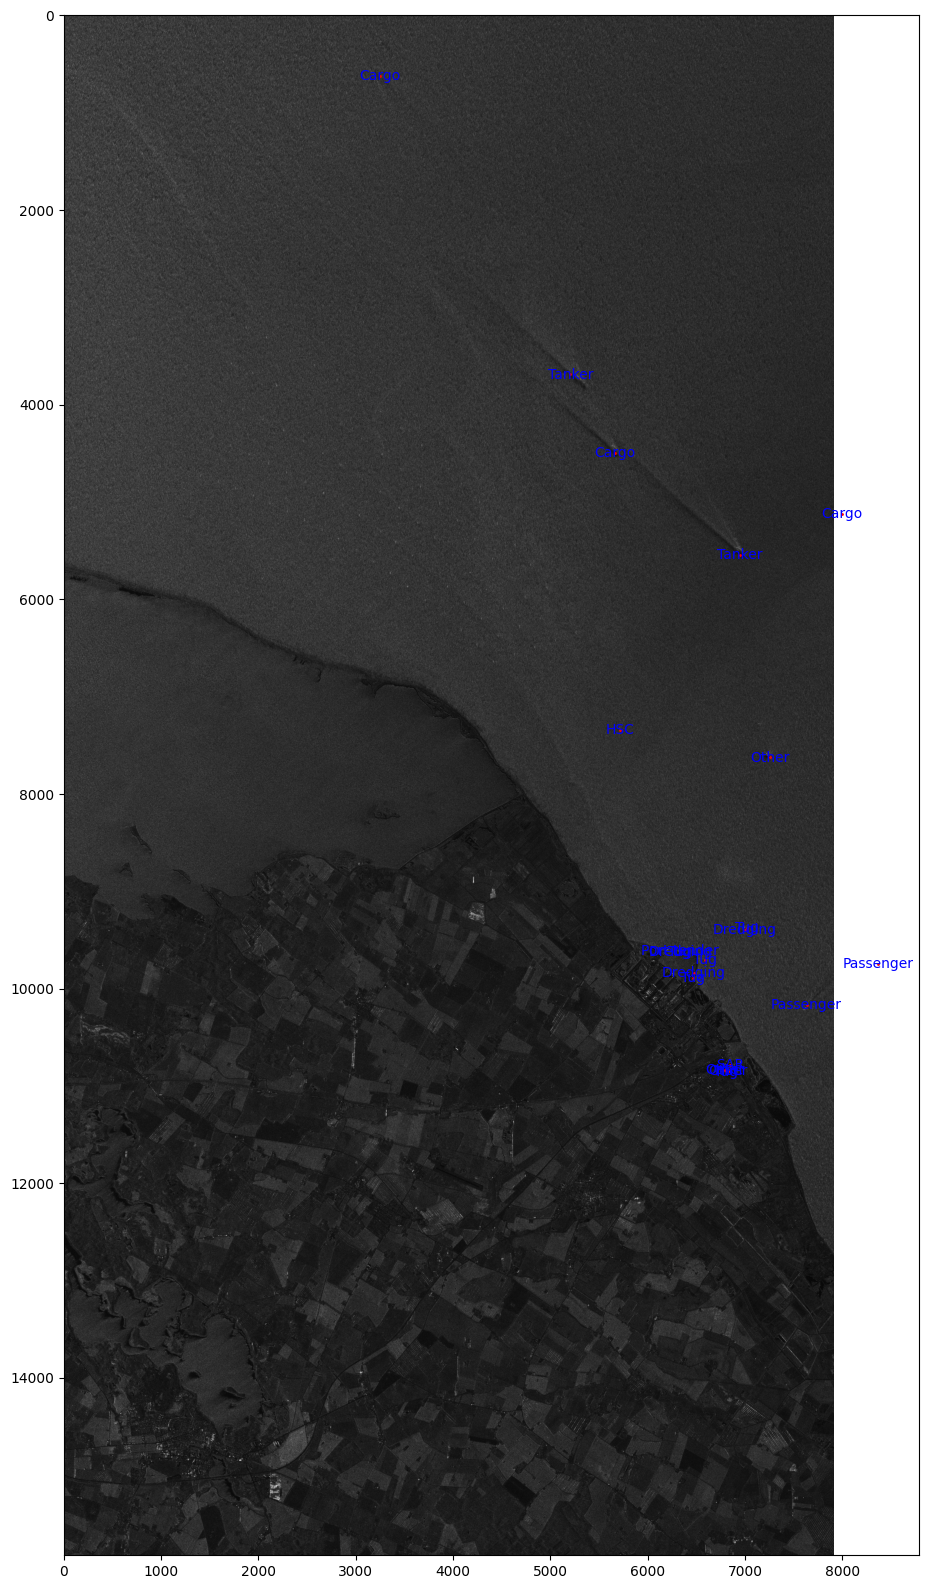

In [22]:
src = rio.open(f'{tii_path}/image_HH_corrected.tif')
plt.figure(figsize=(30, 20))
plt.imshow(src.read(1), cmap='gray', vmin=0, vmax=1500)
plt.scatter(col_AIS, row_AIS, c='red', s=1, label='AIS Points');

for r_ii, c_ii, sh_t_ii in zip(row_AIS, col_AIS, AIS_df['Ship type']):
    plt.text(c_ii, r_ii, f"{sh_t_ii}", fontsize=10, color='blue', ha='center', va='center')

In [46]:
def ship_patches(im_path, im_name,patch_output_dir, AIS_df, row_AIS, col_AIS, h=64, w=64,uint8=False, plt_ptch=False):
    """
    Extract patches from the image based on AIS data and save them to the specified directory.
    
    Parameters:
    - im_path: Path to the input image file.
    - patch_output_dir: Directory where the patches will be saved.
    - row: List of row indices for AIS points.
    - col: List of column indices for AIS points.
    - h: Half height of the patch.
    - w: Half width of the patch.
    """
    import os
    import rasterio as rio
    from rasterio.windows import Window
    import matplotlib.pyplot as plt
    import shutil
    
    if not os.path.exists(patch_output_dir):
        os.makedirs(patch_output_dir)
    else:
        # If the directory already exists, remove its files and create a new one
        shutil.rmtree(patch_output_dir)
        os.makedirs(patch_output_dir)

    if uint8:
        if not os.path.exists(f"{patch_output_dir}_uint8"):
            os.makedirs(f"{patch_output_dir}_uint8")
        else:
            # If the directory already exists, remove its files and create a new one
            shutil.rmtree(f"{patch_output_dir}_uint8")
            os.makedirs(f"{patch_output_dir}_uint8")

    src = rio.open(im_path)
    im  = src.read(1)

    patch_name_all = []
    ii = 1
    for r_ii, c_ii, sh_t_ii in zip(row_AIS, col_AIS, AIS_df['Ship type']):
        if r_ii-h < 0 or r_ii+h >= im.shape[0] or c_ii-w < 0 or c_ii+w >= im.shape[1]:
            print(f"Skipping patch for row {r_ii}, col {c_ii} due to out of bounds.")
            patch_name_all.append('')
            continue
        else:
            subii = im[r_ii-h:r_ii+h, c_ii-w:c_ii+w]
            # Adjust metadata:
            out_meta = src.meta.copy()
            out_meta.update({
                "height"   : h*2,
                "width"    : w*2,
                "transform": src.window_transform( Window(c_ii-w, r_ii-h, 2*w, 2*h) ),
                "compress" :'lzw'
            })
            # Write the output:
            patch_nameii = f"{im_name}_patch_{ii}_{sh_t_ii}"
            patch_name_all.append(patch_nameii)
            out_nameii   = f"{patch_output_dir}/{patch_nameii}.tif"
            with rio.open(out_nameii, "w", **out_meta) as dest:
                dest.write(subii,1)
            
                subii = subii.astype('float32')
                subii -= subii.mean()
                subii /= 5*subii.std()
                subii += 0.5
                subii = (255 * subii).clip(0, 255).astype('uint8')
                
                out_nameii   = f"{patch_output_dir}_uint8/{patch_nameii}_uint8.tif"
                out_meta.update({
                    "dtype": 'uint8',
                })
                with rio.open(out_nameii, "w", **out_meta) as dest:
                    dest.write(subii,1)

            if plt_ptch:
                plt.figure()
                plt.imshow(subii, cmap='gray', vmin=0, vmax=1500)
                plt.text(h, w, f"{sh_t_ii}", fontsize=10, color='blue', ha='center', va='center')

            ii += 1
    AIS_df['Patch_name'] = patch_name_all
    
    return AIS_df

In [47]:
h= 128  # Half height for patch
w= 128  # Half width for patch

patch_output_dir = f"{tii_path}/ship_patches"
AIS_df = ship_patches(im_path=f'{tii_path}/image_HH_corrected.tif', 
                      im_name=im_name,
                      patch_output_dir=patch_output_dir, 
                      AIS_df=AIS_df, 
                      row_AIS=row_AIS, 
                      col_AIS=col_AIS, 
                      h=h, 
                      w=w,
                      uint8=True,
                      plt_ptch=False)

Skipping patch for row 5122, col 7995 due to out of bounds.
Skipping patch for row 9749, col 8368 due to out of bounds.


Export new AIS csv with a column including the Patch names

In [ ]:
# Save the updated AIS data with patch names:
AIS_df.to_csv(f"{tii_path}/AIS.csv", index=False)
print(f"Saved the updataed AIS data with patch_names column to {tii_path}/AIS.csv")

Saved the updataed AIS data with patch_names column to /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/AIS.csv


### Detection

### Download Sentinel (GEE)

In [13]:
import ee
ee.Authenticate()
ee.Initialize()


In [ ]:
ii = 0 
aoi = ee.Geometry.Rectangle([AIS_df['Longitude'][ii]-0.065, AIS_df['Latitude'][ii]-0.065, AIS_df['Longitude'][ii]+0.065, AIS_df['Latitude'][ii]+0.065])

aoi = ee.Geometry.Rectangle([(lon_min+lon_max)/2-0.065, (lat_min+lat_max)/2-0.065, (lon_min+lon_max)/2+0.065, (lat_min+lat_max)/2+0.065])  # Example coordinates, replace with actual values
aoi = ee.Geometry.Rectangle([11.43, 54.55, 11.56, 54.68])  # Example coordinates, replace with actual values

In [15]:
start_date = '2024-04-09'#f"{acqdate0[:8][:4]}-{acqdate0[:8][4:6]}-{acqdate0[:8][6:8]}"  # Extract the date part (YYYY-MM-DD) 
end_date   = '2024-04-15'

In [16]:
# Load Sentinel-1 Collection
sentinel1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filterDate(start_date, end_date) \
    # .filter(ee.Filter.eq('system:index', image_name)) \
    # .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    # .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    # .select(['VV', 'VH'])


image_list = sentinel1.toList(sentinel1.size())

In [17]:
# Print image names
image_name = []
image_list = sentinel1.toList(sentinel1.size())
for ii in range(image_list.size().getInfo()):
    image = ee.Image(image_list.get(ii))
    image_name.append(image.get('system:index').getInfo())
    print(image_name[-1])


S1A_IW_GRDH_1SDV_20240413T165325_20240413T165350_053418_067ACC_B8F3


In [ ]:
import os

download_dir = f"{tii_path}S1"  # Change this path as needed

# Create the directory if it doesn't exist
if not os.path.exists(download_dir):
    os.makedirs(download_dir)

In [21]:
# S1 Download:

# Function to download Sentinel-1 image
# This function downloads the Sentinel-1 image and saves it as a GeoTIFF file
def download_image(image, aoi, download_dir):
    import requests
    orbit_pass = image.get('orbitProperties_pass').getInfo()

    # Generate download URL for the entire image (all bands)
    url = image.getDownloadUrl({
        'scale': 10,
        'region': aoi.getInfo()['coordinates'],
        'format': 'GEO_TIFF',
        'crs': 'EPSG:4326'
    })
    response = requests.get(url)
    
    filename = f"Sentinel1_{image.get('system:index').getInfo()}_{orbit_pass}.tif"
    filepath = os.path.join(download_dir, filename)
    
    with open(filepath, 'wb') as file:
        file.write(response.content)
    
    print(f"Downloaded: {filename} → {download_dir}")



# Loop through images and download each one (with all bands)

for ii in range(image_list.size().getInfo()):
    image = ee.Image(image_list.get(ii))
    image_name = image.get('system:index').getInfo()
    orbit_pass = image.get('orbitProperties_pass').getInfo()
    s1_filename = f"Sentinel1_{image_name}_{orbit_pass}.tif"
    s1_filepath = os.path.join(download_dir, s1_filename)
    if not os.path.exists(s1_filepath):
        print(f"Downloading: {s1_filename}")
        download_image(image, aoi, download_dir)
    else:
        print(f"File already exists: {s1_filename}")

Downloading: Sentinel1_S1A_IW_GRDH_1SDV_20240413T165325_20240413T165350_053418_067ACC_B8F3_ASCENDING.tif
Downloaded: Sentinel1_S1A_IW_GRDH_1SDV_20240413T165325_20240413T165350_053418_067ACC_B8F3_ASCENDING.tif → /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/S1


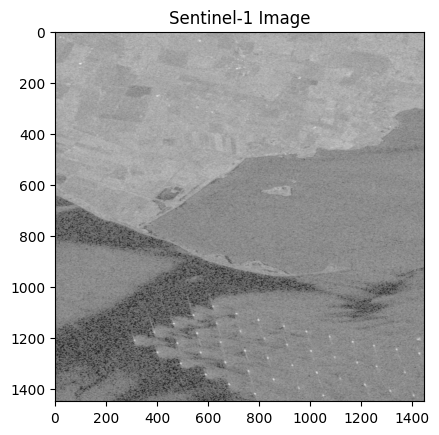

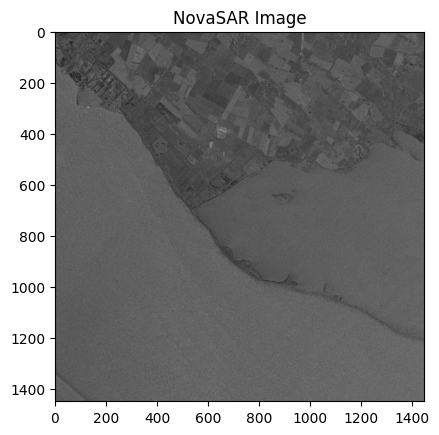

In [50]:
import cv2

s1_src = rio.open(f"{s1_filepath}")
s1_im = s1_src.read(1)
# scale_factor = 4 # Scale factors
# s1_im = cv2.resize(s1_im, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)
s1_im -= s1_im.min()
s1_im /= s1_im.max()  # Normalize to [0, 1]
s1_im *= 255  # Scale to [0, 255]
s1_im = s1_im.astype(np.uint8)  # Convert to uint8 for visualization
plt.figure()
plt.imshow(s1_im, cmap='gray')
plt.title(f"Sentinel-1 Image");


nova_src = s1_src = rio.open(tif_files[tii])
nova_im = np.fliplr(np.flipud(np.log10(nova_src.read(1)))) 
scale_factor = 1/4 # Scale factors
nova_im = cv2.resize(nova_im, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)

nova_im = nova_im[nova_im.shape[0]//2-s1_im.shape[0]//2:nova_im.shape[0]//2+s1_im.shape[0]//2, nova_im.shape[1]//2-s1_im.shape[1]//2:nova_im.shape[1]//2+s1_im.shape[1]//2]  # Crop to the lower right quadrant
nova_im -= nova_im.min()
nova_im /= nova_im.max()  # Normalize to [0, 1]
nova_im *= 255  # Scale to [0, 255]
nova_im = nova_im.astype(np.uint8)  # Convert to uint8 for visualization
plt.figure()
plt.imshow(nova_im, cmap='gray')
plt.title(f"NovaSAR Image");







### NovaSAR - S1 Matching

In [53]:
import cv2

# Initialize ORB detector
# orb = cv2.ORB_create()
sift = cv2.SIFT_create()


# Find keypoints and descriptors
# kp1, des1 = orb.detectAndCompute(nova_im, None)
# kp2, des2 = orb.detectAndCompute(s1_im, None)

kp1, des1 = sift.detectAndCompute(nova_im[:3500,:], None)
kp2, des2 = sift.detectAndCompute(s1_im[:3500,:], None)

# Match descriptors using Brute-Force matcher
# bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

matches = bf.match(des1, des2)

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# Take the top 90 % matches forward.
matches = matches[:int(len(matches)*0.1)]
no_of_matches = len(matches)

# Define empty matrices of shape no_of_matches * 2.
p_nova = np.zeros((no_of_matches, 2))
p_s1 = np.zeros((no_of_matches, 2))
for ii in range(len(matches)):
  p_nova[ii, :] = kp1[matches[ii].queryIdx].pt
  p_s1[ii, :] = kp2[matches[ii].trainIdx].pt

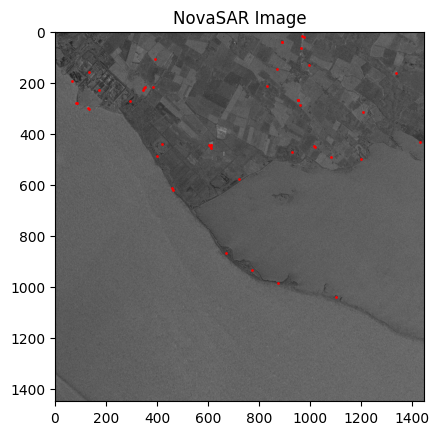

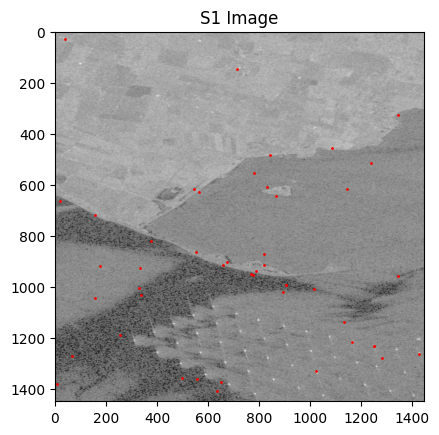

In [54]:
plt.figure()
plt.imshow(nova_im, cmap='gray')
plt.scatter(p_nova[:, 0], p_nova[:, 1], c='r', s=1, label='NovaSAR Keypoints')
plt.title(f"NovaSAR Image");

plt.figure()
plt.imshow(s1_im, cmap='gray')
plt.scatter(p_s1[:, 0], p_s1[:, 1], c='r', s=1, label='S1 Keypoints')
plt.title(f"S1 Image");